In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive/insar/2021/training*

/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210125T005115Z_v1.0_20250418T132023Z.nc
/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210206T005115Z_v1.0_20250418T132023Z.nc
/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210218T005114Z_v1.0_20250418T132023Z.nc
/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210302T005114Z_v1.0_20250418T132023Z.nc
/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210314T005114Z_v1.0_20250418T132023Z.nc
/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210326T005115Z_v1.0_20250418T132023Z.nc
/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210407T005115Z_v1.0_20250418T132023Z.nc
/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_202

In [6]:
import xarray as xr
ds_train = xr.open_dataset('/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210125T005115Z_v1.0_20250418T132023Z.nc')
ds_train

<xarray.Dataset> Size: 126MB
Dimensions:       (lat: 1931, lon: 2724)
Coordinates:
  * lon           (lon) float64 22kB -106.1 -106.1 -106.1 ... -103.1 -103.1
  * lat           (lat) float64 15kB 32.68 32.68 32.68 ... 30.52 30.52 30.51
    spatial_ref   int64 8B ...
Data variables:
    displacement  (lat, lon) float64 42MB ...
    s1_start      (lat, lon) float64 42MB ...
    s1_end        (lat, lon) float64 42MB ...

Text(0.5, 0.98, 'training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210125T005115Z_v1.0_20250418T132023Z')

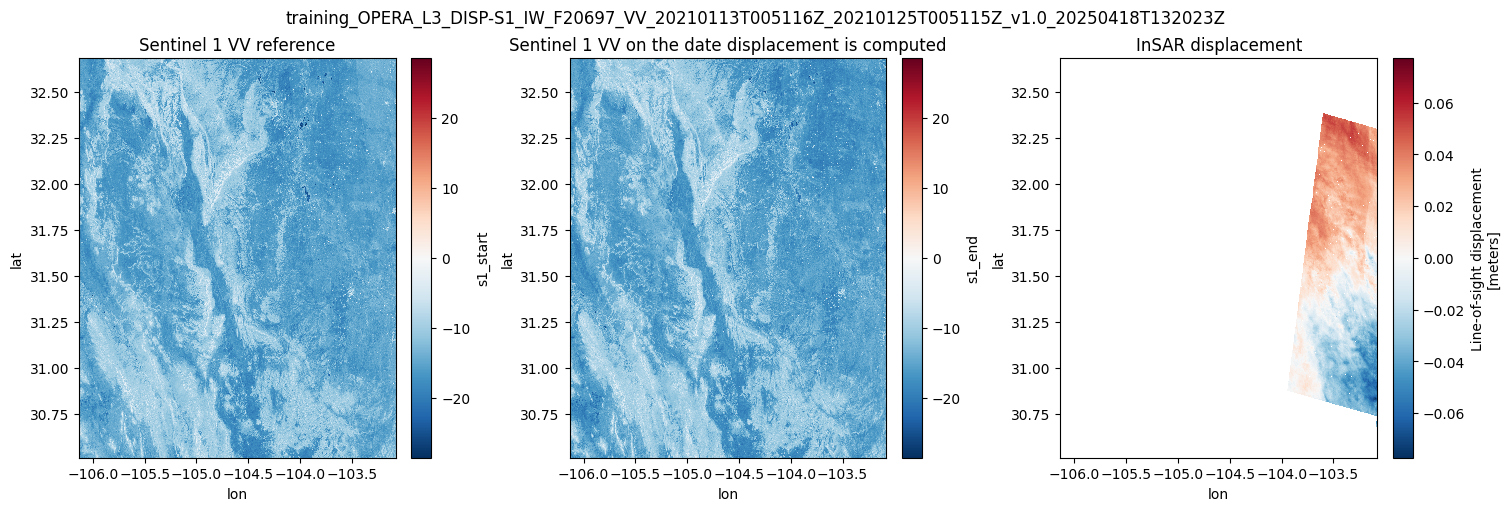

In [11]:
import matplotlib.pyplot as plt
from pathlib import Path
# Path to your NetCDF file
path = '/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210125T005115Z_v1.0_20250418T132023Z.nc'

ds_train = xr.open_dataset(path)
# assume your dataset is named `ds`
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ds_train.displacement.plot(ax=axs[2])
ds_train.s1_start.plot(ax=axs[0])
ds_train.s1_end.plot(ax=axs[1])
axs[0].set_title('Sentinel 1 VV reference')
axs[1].set_title('Sentinel 1 VV on the date displacement is computed')
axs[2].set_title('InSAR displacement')
# Use the filename (no path, no .nc) as the suptitle
fig.suptitle(Path(path).stem)

Text(0.5, 0.98, 'training_OPERA_L3_DISP-S1_IW_F40297_VV_20210903T005940Z_20211102T005941Z_v1.0_20250418T114525Z')

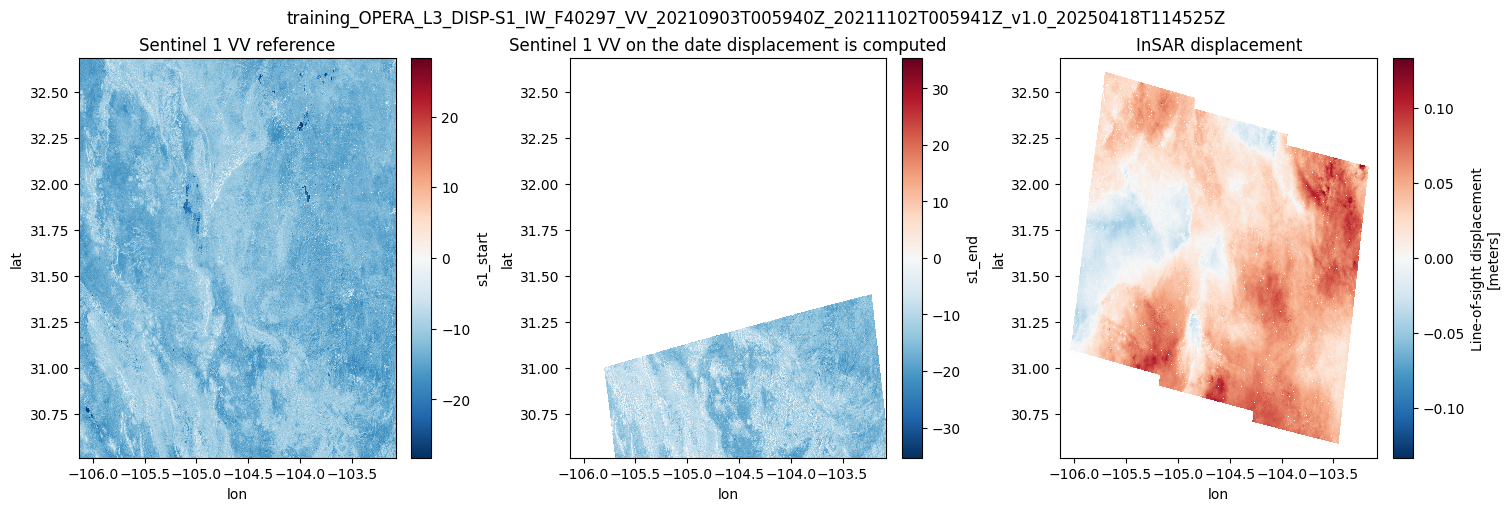

In [12]:
import matplotlib.pyplot as plt
from pathlib import Path
# Path to your NetCDF file

path = '/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F40297_VV_20210903T005940Z_20211102T005941Z_v1.0_20250418T114525Z.nc'
ds_train = xr.open_dataset(path)
# assume your dataset is named `ds`
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ds_train.displacement.plot(ax=axs[2])
ds_train.s1_start.plot(ax=axs[0])
ds_train.s1_end.plot(ax=axs[1])
axs[0].set_title('Sentinel 1 VV reference')
axs[1].set_title('Sentinel 1 VV on the date displacement is computed')
axs[2].set_title('InSAR displacement')
# Use the filename (no path, no .nc) as the suptitle
fig.suptitle(Path(path).stem)

In [13]:
# --- Setup & file split ---
import os, glob, math, random
from pathlib import Path

import xarray as xr
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# 1) Count files
pattern = "/content/drive/MyDrive/insar/2021/training*"
all_files = sorted([p for g in glob.glob(pattern) for p in (glob.glob(os.path.join(g, "*.nc")) if os.path.isdir(g) else ([g] if g.endswith(".nc") else []))])
print(f"Found {len(all_files)} .nc files")

# 2) 70/30 split (deterministic)
train_count = int(len(all_files) * 0.7)
train_files = all_files[:train_count]
val_files   = all_files[train_count:]
print(f"Train: {len(train_files)} | Val: {len(val_files)}")

Found 119 .nc files
Train: 83 | Val: 36


# Compute min max

In [14]:
# --- Global min/max over training files only ---
import json

vars_to_check = ["s1_start", "s1_end", "displacement"]

# init running stats
stats = {v: {"min": np.inf, "max": -np.inf, "count_finite": 0} for v in vars_to_check}

for path in train_files:
    try:
        with xr.open_dataset(path) as ds:
            for v in vars_to_check:
                if v not in ds.variables:
                    continue
                arr = ds[v].values  # numpy array
                finite = np.isfinite(arr)
                if not finite.any():
                    continue
                vmin = np.nanmin(arr[finite])
                vmax = np.nanmax(arr[finite])
                # update running min/max and count of finite elements
                if vmin < stats[v]["min"]:
                    stats[v]["min"] = vmin
                if vmax > stats[v]["max"]:
                    stats[v]["max"] = vmax
                stats[v]["count_finite"] += int(finite.sum())
    except Exception as e:
        print(f"[warn] Skipping {path}: {e}")

# clean up infs if a variable never had finite values
for v in vars_to_check:
    if not np.isfinite(stats[v]["min"]):
        stats[v]["min"] = None
    if not np.isfinite(stats[v]["max"]):
        stats[v]["max"] = None

print("Training min/max (finite values only):")
for v in vars_to_check:
    print(f"  {v:13s}  min={stats[v]['min']}   max={stats[v]['max']}   count={stats[v]['count_finite']}")

# (optional) save for later normalization use
with open("/content/minmax_stats.json", "w") as f:
    json.dump(stats, f, indent=2)
print("Saved to /content/minmax_stats.json")

Exception ignored in: <function File.close at 0x7ba0183159e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/h5netcdf/core.py", line 1708, in close
    self._h5file.close()
  File "/usr/local/lib/python3.12/dist-packages/h5py/_hl/files.py", line 630, in close
    self.id._close_open_objects(h5f.OBJ_LOCAL | h5f.OBJ_FILE)
  File "h5py/_objects.pyx", line 56, in h5py._objects.with_phil.wrapper
  File "h5py/_objects.pyx", line 57, in h5py._objects.with_phil.wrapper
  File "h5py/h5f.pyx", line 355, in h5py.h5f.FileID._close_open_objects
RuntimeError: Can't decrement id ref count (unable to close file, errno = 107, error message = 'Transport endpoint is not connected')


[warn] Skipping /content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210218T005114Z_v1.0_20250418T132023Z.nc: "Unable to synchronously open object (file read failed: time = Mon Sep 29 04:54:40 2025\n, filename = '/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210218T005114Z_v1.0_20250418T132023Z.nc', file descriptor = 61, errno = 103, error message = 'Software caused connection abort', buf = 0x42e619b0, total read size = 164, bytes this sub-read = 164, offset = 84918011)"
[warn] Skipping /content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210302T005114Z_v1.0_20250418T132023Z.nc: did not find a match in any of xarray's currently installed IO backends ['h5netcdf', 'scipy']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/ins

/usr/local/lib/python3.12/dist-packages/xarray/backends/api.py:741: RuntimeWarning: 'h5netcdf' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
/usr/local/lib/python3.12/dist-packages/xarray/backends/api.py:741: RuntimeWarning: 'scipy' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
/usr/local/lib/python3.12/dist-packages/xarray/backends/api.py:741: RuntimeWarning: 'netcdf4' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


Saved to /content/minmax_stats.json


# Patchify

In [15]:
import numpy as np

def unpatchify(patches, img_shape):
    patch_size = patches.shape[1]
    assert patches.shape[0] == (img_shape[0] // patch_size) * (img_shape[1] // patch_size), "Patches and image shape are not compatible"

    img = np.zeros(img_shape, dtype=patches.dtype)
    patch_idx = 0

    for i in range(0, img_shape[0], patch_size):
        for j in range(0, img_shape[1], patch_size):
            img[i:i + patch_size, j:j + patch_size] = patches[patch_idx]
            patch_idx += 1

    return img

def patchify(img, patch_size):
    img_shape = img.shape
    patches = np.array([img[i:i + patch_size, j:j + patch_size] for i in range(0, img_shape[0], patch_size) for j in range(0, img_shape[1], patch_size)])
    return patches

In [19]:
path = '/content/drive/MyDrive/insar/2021/training_OPERA_L3_DISP-S1_IW_F40297_VV_20210903T005940Z_20211102T005941Z_v1.0_20250418T114525Z.nc'
ds_train = xr.open_dataset(path)
y_train = ds_train.displacement.values[:1920, :2688]
x_train1 = ds_train.s1_start.values[:1920, :2688]
x_train2 = ds_train.s1_end.values[:1920, :2688]

In [20]:
x_train1.shape, x_train2.shape, y_train.shape

((1920, 2688), (1920, 2688), (1920, 2688))

In [53]:
# Create patches from the image
patch_size = 32
img = x_train1
patches = patchify(img, patch_size)

In [54]:
patches.shape

(5040, 32, 32)

In [55]:
# Reconstruct the image from the patches
reconstructed_img = unpatchify(patches, img.shape)

In [56]:
# Check if the reconstructed image is the same as the original image
assert np.allclose(reconstructed_img, img), "The reconstructed image is not the same as the original image"

In [57]:
np.sum(reconstructed_img == img)

np.int64(5160960)

In [58]:
img.shape

(1920, 2688)

In [59]:
1920*2688

5160960

In [60]:
path = train_files[10]
ds_train = xr.open_dataset(path)
y_train = ds_train.displacement.values[:1920, :2688]
x_train1 = ds_train.s1_start.values[:1920, :2688]
x_train2 = ds_train.s1_end.values[:1920, :2688]

x_train_max = 12.60
y_train_max = 0.057

x_train_min = -28.56
y_train_min = -0.077

x_train1 = (x_train1 - x_train_min) / (x_train_max - x_train_min)
x_train2 = (x_train2 - x_train_min) / (x_train_max - x_train_min)
y_train = (y_train - y_train_min) / (y_train_max - y_train_min)

x_train1_patches = patchify(x_train1, patch_size)
x_train2_patches = patchify(x_train2, patch_size)
x1 = np.expand_dims(x_train1_patches, axis=1)  # (315, 1, 128, 128)
x2 = np.expand_dims(x_train2_patches, axis=1)  # (315, 1, 128, 128)
x_train_patches = np.concatenate([x1, x2], axis=1)  # (315, 2, 128, 128)

y_train_patches = patchify(y_train, patch_size)[:, np.newaxis, :, :]
x_train1_patches.shape, x_train2_patches.shape, y_train_patches.shape, x_train_patches.shape

((5040, 32, 32), (5040, 32, 32), (5040, 1, 32, 32), (5040, 2, 32, 32))

In [61]:
bad_x = np.isnan(x_train_patches).any(axis=(1, 2, 3))
bad_y = np.isnan(y_train_patches).any(axis=(1, 2, 3))
keep = ~(bad_x | bad_y)

x_train_patches = x_train_patches[keep]
y_train_patches = y_train_patches[keep]

print(f"Kept {keep.sum()} / {keep.size} samples")
print(x_train_patches.shape, y_train_patches.shape)

Kept 25 / 5040 samples
(25, 2, 32, 32) (25, 1, 32, 32)


In [62]:
path = val_files[0]
ds_val = xr.open_dataset(path)
y_val = ds_val.displacement.values[:1920, :2688]
x_val1 = ds_val.s1_start.values[:1920, :2688]
x_val2 = ds_val.s1_end.values[:1920, :2688]

# x_train_max = 12.60
# y_train_max = 0.057

# x_train_min = -28.56
# y_train_min = -0.077

x_val1 = (x_val1 - x_train_min) / (x_train_max - x_train_min)
x_val2 = (x_val2 - x_train_min) / (x_train_max - x_train_min)
y_val = (y_val - y_train_min) / (y_train_max - y_train_min)

x_val1_patches = patchify(x_val1, patch_size)
x_val2_patches = patchify(x_val2, patch_size)

x1 = np.expand_dims(x_val1_patches, axis=1)  # (315, 1, 128, 128)
x2 = np.expand_dims(x_val2_patches, axis=1)  # (315, 1, 128, 128)
x_val_patches = np.concatenate([x1, x2], axis=1)  # (315, 2, 128, 128)

y_val_patches = patchify(y_val, patch_size)[:, np.newaxis, :, :]
x_val1_patches.shape, x_val2_patches.shape, y_val_patches.shape, x_val_patches.shape

((5040, 32, 32), (5040, 32, 32), (5040, 1, 32, 32), (5040, 2, 32, 32))

In [63]:
bad_x = np.isnan(x_val_patches).any(axis=(1, 2, 3))
bad_y = np.isnan(y_val_patches).any(axis=(1, 2, 3))
keep = ~(bad_x | bad_y)

x_val_patches = x_val_patches[keep]
y_val_patches = y_val_patches[keep]

print(f"Kept {keep.sum()} / {keep.size} samples")
print(x_val_patches.shape, y_val_patches.shape)

Kept 33 / 5040 samples
(33, 2, 32, 32) (33, 1, 32, 32)


In [84]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torch.optim as optim
class ncDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets

    def __getitem__(self, index):
        x = torch.from_numpy(self.data[index])
        y = torch.from_numpy(self.targets[index])
        # x = self.data[index]
        # y = self.targets[index]
        # x = x.to(dtype=torch.float32)
        # y = y.to(dtype=torch.float32)
        return x, y

    def __len__(self):
        return len(self.data)

In [85]:
def train(model, train_dataloader, val_dataloader, criterion, optimizer, device):
    model.train()
    train_loss = 0.0
    for batch in train_dataloader:
        lr, hr = batch
        lr, hr = lr.to(device=device, dtype=torch.float32), hr.to(device=device, dtype=torch.float32)
        optimizer.zero_grad()
        sr = model(lr)
        loss = criterion(sr, hr)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_dataloader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:
            lr, hr = batch
            lr, hr = lr.to(device=device, dtype=torch.float32), hr.to(device=device, dtype=torch.float32)
            sr = model(lr)
            loss = criterion(sr, hr)
            val_loss += loss.item()

    val_loss /= len(val_dataloader)

    return train_loss, val_loss

In [86]:
class SRCNN(nn.Module):
    def __init__(self):
        super(SRCNN, self).__init__()
        self.conv1 = nn.Conv2d(2, 64, kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=1, padding=0)
        self.conv3 = nn.Conv2d(32, 1, kernel_size=5, padding=2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x

In [87]:
train_dataset = ncDataset(x_train_patches, y_train_patches)
val_dataset = ncDataset(x_val_patches, y_val_patches)

In [88]:
lr, hr = train_dataset.__getitem__(0)
print(lr.shape, hr.shape, train_dataset.__len__())

torch.Size([2, 32, 32]) torch.Size([1, 32, 32]) 25


In [89]:
train_dataloader = DataLoader(train_dataset, batch_size=20, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=20, shuffle=True)

In [90]:
for batch in train_dataloader:
    data, targets = batch
    print(data.size())  # Should print torch.Size([16, 1, 30, 30])
    print(targets.size())  # Should print torch.Size([16, 1, 30, 601])
    break

torch.Size([20, 2, 32, 32])
torch.Size([20, 1, 32, 32])


In [91]:
device = 'cuda'
model = SRCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [92]:
from copy import deepcopy
is_train = True
num_epochs = 1000
print_interval = 10
patience = 50
best_val_loss = float('inf')
counter = 0
best_model = None

if is_train:
    for epoch in range(1, num_epochs + 1):
        train_loss, val_loss = train(model, train_dataloader, val_dataloader, criterion, optimizer, device)
    # Log losses to TensorBoard

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = deepcopy(model)
            counter = 0
        else:
            counter += 1

        if epoch % print_interval == 0:
            print(f"Epoch [{epoch}/{num_epochs}] - Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch [10/1000] - Train Loss: 0.0736, Validation Loss: 0.0301
Epoch [20/1000] - Train Loss: 0.0475, Validation Loss: 0.0461
Epoch [30/1000] - Train Loss: 0.0481, Validation Loss: 0.0389
Epoch [40/1000] - Train Loss: 0.0581, Validation Loss: 0.0277
Epoch [50/1000] - Train Loss: 0.0458, Validation Loss: 0.0436
Epoch [60/1000] - Train Loss: 0.0433, Validation Loss: 0.0286
Epoch [70/1000] - Train Loss: 0.0407, Validation Loss: 0.0426
Epoch [80/1000] - Train Loss: 0.0439, Validation Loss: 0.0474
Epoch [90/1000] - Train Loss: 0.0463, Validation Loss: 0.0632
Early stopping triggered.


# Loop over all train files

In [102]:
import random
import numpy as np
import xarray as xr
import torch
from copy import deepcopy

# ----- config (keep your values) -----
patch_size = 32                # <- your original patchify expects an int
H, W = 1920, 2688
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 20
epochs_per_train_file = 1000       # do 1 epoch per train file; bump if you want more
print_interval = 10
patience = 50

# normalization (yours)
x_train_max = 12.60; x_train_min = -28.56
y_train_max = 0.057; y_train_min = -0.077

def norm_x(a): return (a - x_train_min) / (x_train_max - x_train_min)
def norm_y(a): return (a - y_train_min) / (y_train_max - y_train_min)

def build_patches_from_path(path):
    ds = xr.open_dataset(path)
    y = ds.displacement.values[:H, :W]
    x1 = ds.s1_start.values[:H, :W]
    x2 = ds.s1_end.values[:H, :W]
    ds.close()

    x1 = norm_x(x1); x2 = norm_x(x2); y = norm_y(y)

    x1_p = patchify(x1, patch_size)                       # (N, 128, 128)
    x2_p = patchify(x2, patch_size)                       # (N, 128, 128)
    y_p  = patchify(y,  patch_size)[:, np.newaxis, :, :]  # (N, 1, 128, 128)

    x1_p = np.expand_dims(x1_p, axis=1)                   # (N, 1, 128, 128)
    x2_p = np.expand_dims(x2_p, axis=1)                   # (N, 1, 128, 128)
    X = np.concatenate([x1_p, x2_p], axis=1)              # (N, 2, 128, 128)

    bad_x = np.isnan(X).any(axis=(1,2,3))
    bad_y = np.isnan(y_p).any(axis=(1,2,3))
    keep = ~(bad_x | bad_y)

    return X[keep], y_p[keep]

# ----- reuse your Dataset / model / train() -----
# ncDataset, SRCNN, train() assumed already defined exactly as in your snippet

model = SRCNN().to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_val_loss = float('inf')
best_model = None
counter = 0
step = 0

for ti, train_path in enumerate(train_files, start=1):
    # build TRAIN from this one file
    try:
        x_train_patches, y_train_patches = build_patches_from_path(train_path)
        train_dataset = ncDataset(x_train_patches, y_train_patches)
        train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        # pick ONE random VAL file for this train file
        v_idx = random.randrange(len(val_files))
        val_path = val_files[v_idx]
        x_val_patches, y_val_patches = build_patches_from_path(val_path)
        val_dataset = ncDataset(x_val_patches, y_val_patches)
        val_loader  = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # run a few epochs on this train file
        for ep in range(1, epochs_per_train_file + 1):
            train_loss, val_loss = train(model, train_loader, val_loader, criterion, optimizer, device)
            step += 1

            # early-stopping tracking across the whole run
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = deepcopy(model)
                counter = 0
                improved = True
            else:
                counter += 1
                improved = False

            if (step % print_interval == 0) or improved:
                print(f"[file {ti}/{len(train_files)} | val_file idx {v_idx}] "
                    f"step {step} | train {train_loss:.6f} | val {val_loss:.6f}"
                    f"{' (best)' if improved else ''}")

            if counter >= patience:
                print("Early stopping triggered.")
                break

        if counter >= patience:
            continue
    except Exception as e:
        print(f"[warn] Skipping {train_path}: {e}")

print("Done. Best val loss:", best_val_loss)
# best_model holds the best weights

[file 1/83 | val_file idx 16] step 1 | train 0.392502 | val 0.160446 (best)
[file 1/83 | val_file idx 16] step 2 | train 0.218257 | val 0.112565 (best)
[file 1/83 | val_file idx 16] step 10 | train 0.066838 | val 0.129164
[file 1/83 | val_file idx 16] step 20 | train 0.042974 | val 0.192065
[file 1/83 | val_file idx 16] step 30 | train 0.041650 | val 0.182274
[file 1/83 | val_file idx 16] step 40 | train 0.036936 | val 0.176153
[file 1/83 | val_file idx 16] step 50 | train 0.027394 | val 0.152447
Early stopping triggered.
Early stopping triggered.
[file 3/83 | val_file idx 6] step 54 | train 0.008614 | val 0.007095 (best)
[file 3/83 | val_file idx 6] step 57 | train 0.006597 | val 0.006676 (best)
[file 3/83 | val_file idx 6] step 59 | train 0.007049 | val 0.006391 (best)
[file 3/83 | val_file idx 6] step 60 | train 0.006153 | val 0.007247
[file 3/83 | val_file idx 6] step 62 | train 0.005386 | val 0.006169 (best)
[file 3/83 | val_file idx 6] step 63 | train 0.006253 | val 0.006048 (bes